<a href="https://colab.research.google.com/github/srilakshmi-saladi/unet/blob/main/xray_pneumonia_classification_models_updated_88_90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chest X-Ray Pneumonia Classification (Updated for Your Drive Structure)

This notebook is for the Kaggle **Chest X-Ray Images (Pneumonia)** dataset.

It is updated for your Google Drive structure, where the dataset appears under:

- `MyDrive/X-ray/chest_xray`

and may also contain extra folders like:
- `__MACOSX`
- nested `chest_xray`
- `.DS_Store`

The notebook auto-detects the correct folder containing:
- `train`
- `val`
- `test`

## Models compared
- DenseNet121
- ResNet50

## Outputs
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion matrix
- ROC curve
- Final comparison CSV

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import DenseNet121, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def cleanup_memory():
    gc.collect()
    tf.keras.backend.clear_session()

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
# ============================================
# CONFIG (AUTO-DETECT BASE DIRECTORY)
# ============================================
BASE_CANDIDATES = [
    "/content/drive/MyDrive/X-ray/chest_xray",
    "/content/drive/MyDrive/X-ray/chest_xray/chest_xray",
]

BASE_DIR = None
for p in BASE_CANDIDATES:
    if (
        os.path.exists(os.path.join(p, "train")) and
        os.path.exists(os.path.join(p, "val")) and
        os.path.exists(os.path.join(p, "test"))
    ):
        BASE_DIR = p
        break

assert BASE_DIR is not None, "Could not find dataset folder with train/val/test"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

HEAD_EPOCHS = 8
FINE_TUNE_EPOCHS = 5

SAVE_DIR = os.path.join(BASE_DIR, "xray_model_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

print("Using BASE_DIR:", BASE_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("SAVE_DIR:", SAVE_DIR)

Using BASE_DIR: /content/drive/MyDrive/X-ray/chest_xray
TRAIN_DIR: /content/drive/MyDrive/X-ray/chest_xray/train
VAL_DIR: /content/drive/MyDrive/X-ray/chest_xray/val
TEST_DIR: /content/drive/MyDrive/X-ray/chest_xray/test
SAVE_DIR: /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs


In [4]:
# ============================================
# VERIFY DATASET
# ============================================
required_paths = [
    TRAIN_DIR, VAL_DIR, TEST_DIR,
    os.path.join(TRAIN_DIR, "NORMAL"),
    os.path.join(TRAIN_DIR, "PNEUMONIA"),
    os.path.join(VAL_DIR, "NORMAL"),
    os.path.join(VAL_DIR, "PNEUMONIA"),
    os.path.join(TEST_DIR, "NORMAL"),
    os.path.join(TEST_DIR, "PNEUMONIA"),
]

for p in required_paths:
    print(p, "->", os.path.exists(p))

assert all(os.path.exists(p) for p in required_paths), "Dataset folders are missing. Check BASE_DIR."

def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

summary_df = pd.DataFrame({
    "Split": ["Train", "Train", "Val", "Val", "Test", "Test"],
    "Class": ["NORMAL", "PNEUMONIA", "NORMAL", "PNEUMONIA", "NORMAL", "PNEUMONIA"],
    "Count": [
        count_images(os.path.join(TRAIN_DIR, "NORMAL")),
        count_images(os.path.join(TRAIN_DIR, "PNEUMONIA")),
        count_images(os.path.join(VAL_DIR, "NORMAL")),
        count_images(os.path.join(VAL_DIR, "PNEUMONIA")),
        count_images(os.path.join(TEST_DIR, "NORMAL")),
        count_images(os.path.join(TEST_DIR, "PNEUMONIA")),
    ]
})

display(summary_df)

/content/drive/MyDrive/X-ray/chest_xray/train -> True
/content/drive/MyDrive/X-ray/chest_xray/val -> True
/content/drive/MyDrive/X-ray/chest_xray/test -> True
/content/drive/MyDrive/X-ray/chest_xray/train/NORMAL -> True
/content/drive/MyDrive/X-ray/chest_xray/train/PNEUMONIA -> True
/content/drive/MyDrive/X-ray/chest_xray/val/NORMAL -> True
/content/drive/MyDrive/X-ray/chest_xray/val/PNEUMONIA -> True
/content/drive/MyDrive/X-ray/chest_xray/test/NORMAL -> True
/content/drive/MyDrive/X-ray/chest_xray/test/PNEUMONIA -> True


,Split,Class,Count
0,Train,NORMAL,1341
1,Train,PNEUMONIA,3875
2,Val,NORMAL,8
3,Val,PNEUMONIA,8
4,Test,NORMAL,234
5,Test,PNEUMONIA,390


In [5]:
# ============================================
# GENERATORS
# ============================================
def make_generators(preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.08,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=True,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_directory(
        VAL_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    test_gen = eval_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [6]:
# ============================================
# MODEL BUILDERS
# ============================================
def build_densenet121():
    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.20)(x)
    output = Dense(1, activation="sigmoid", dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model, densenet_preprocess


def build_resnet50():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.20)(x)
    output = Dense(1, activation="sigmoid", dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model, resnet_preprocess

In [7]:
# ============================================
# TRAIN + EVALUATE
# ============================================
LOSS_FN = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)

def train_and_evaluate(model_name, build_fn, unfreeze_layers=20):
    cleanup_memory()

    model, base_model, preprocess_fn = build_fn()
    train_gen, val_gen, test_gen = make_generators(preprocess_fn)

    ckpt_head = os.path.join(SAVE_DIR, f"{model_name}_head_best.keras")
    ckpt_ft   = os.path.join(SAVE_DIR, f"{model_name}_ft_best.keras")
    log_head  = os.path.join(SAVE_DIR, f"{model_name}_head_log.csv")
    log_ft    = os.path.join(SAVE_DIR, f"{model_name}_ft_log.csv")

    callbacks_head = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-7, verbose=1),
        ModelCheckpoint(filepath=ckpt_head, monitor="val_loss", save_best_only=True, verbose=1),
        CSVLogger(log_head)
    ]

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=LOSS_FN,
        metrics=["accuracy"]
    )

    history_head = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=HEAD_EPOCHS,
        callbacks=callbacks_head,
        verbose=1
    )

    best_model = tf.keras.models.load_model(ckpt_head)

    for layer in best_model.layers:
        layer.trainable = False
    for layer in best_model.layers[-unfreeze_layers:]:
        layer.trainable = True

    callbacks_ft = [
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-7, verbose=1),
        ModelCheckpoint(filepath=ckpt_ft, monitor="val_loss", save_best_only=True, verbose=1),
        CSVLogger(log_ft)
    ]

    best_model.compile(
        optimizer=Adam(learning_rate=5e-6),
        loss=LOSS_FN,
        metrics=["accuracy"]
    )

    history_ft = best_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks_ft,
        verbose=1
    )

    final_model = tf.keras.models.load_model(ckpt_ft)

    test_gen.reset()
    test_loss, test_acc = final_model.evaluate(test_gen, verbose=1)

    test_gen.reset()
    y_prob = final_model.predict(test_gen, verbose=1).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_gen.classes

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return {
        "Model": model_name,
        "Test Loss": float(test_loss),
        "Accuracy": float(test_acc),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
        "ROC-AUC": float(auc),
        "Saved Model": ckpt_ft
    }, history_head.history, history_ft.history

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8993 - loss: 0.3102 
Epoch 1: val_loss improved from None to 0.32589, saving model to /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/DenseNet121_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/DenseNet121_head_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 2783s 17s/step - accuracy: 0.9335 - loss: 0.2567 - val_accuracy: 0.9375 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.9625 - loss: 0.2146
Epoch 2: val_loss improved from 0.32589 to 0.31440, saving model to /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/DenseNet121_head_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/X-ray/chest_xray/xray_

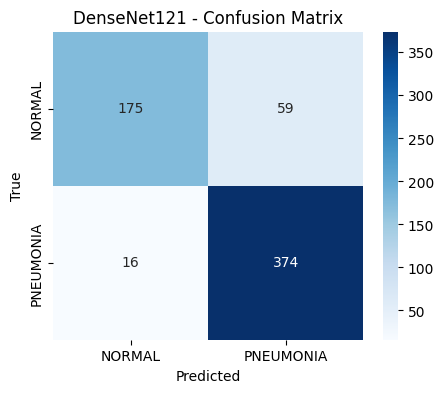

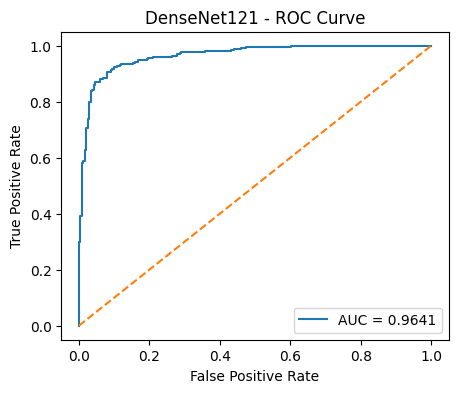

{'Model': 'DenseNet121',
 'Test Loss': 0.3355686366558075,
 'Accuracy': 0.879807710647583,
 'Precision': 0.8637413394919169,
 'Recall': 0.958974358974359,
 'F1': 0.9088699878493317,
 'ROC-AUC': 0.9641025641025641,
 'Saved Model': '/content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/DenseNet121_ft_best.keras'}

In [8]:
# ============================================
# TRAIN DENSENET121
# ============================================
result_densenet, hist_dn_head, hist_dn_ft = train_and_evaluate(
    model_name="DenseNet121",
    build_fn=build_densenet121,
    unfreeze_layers=20
)

result_densenet

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.9247 - loss: 0.3222
Epoch 1: val_loss improved from None to 0.23039, saving model to /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/ResNet50_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/ResNet50_head_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 162s 896ms/step - accuracy: 0.9429 - loss: 0.2732 - val_accuracy: 1.0000 - val_loss: 0.2304 - learning_rate: 0.0010
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.9610 - loss: 0.2194
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_loss did not improve from 0.23039
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 779ms/step - accuracy: 0.9603 - loss: 0.2221 - val_accuracy: 0.9375 - val_loss: 0

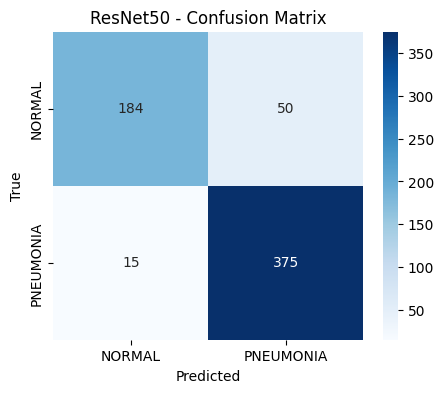

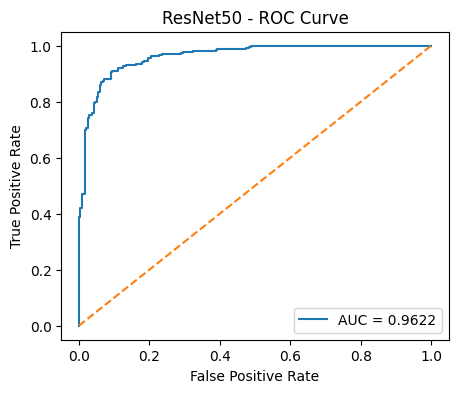

{'Model': 'ResNet50',
 'Test Loss': 0.32256487011909485,
 'Accuracy': 0.8958333134651184,
 'Precision': 0.8823529411764706,
 'Recall': 0.9615384615384616,
 'F1': 0.9202453987730062,
 'ROC-AUC': 0.9621959237343853,
 'Saved Model': '/content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/ResNet50_ft_best.keras'}

In [9]:
# ============================================
# TRAIN RESNET50
# ============================================
result_resnet, hist_rs_head, hist_rs_ft = train_and_evaluate(
    model_name="ResNet50",
    build_fn=build_resnet50,
    unfreeze_layers=15
)

result_resnet

In [10]:
# ============================================
# COMPARE RESULTS
# ============================================
comparison_df = pd.DataFrame([result_densenet, result_resnet])
comparison_df = comparison_df.sort_values(by=["Accuracy", "F1", "ROC-AUC"], ascending=False).reset_index(drop=True)

display(comparison_df)

comparison_csv = os.path.join(SAVE_DIR, "xray_model_comparison.csv")
comparison_df.to_csv(comparison_csv, index=False)
print("Saved comparison to:", comparison_csv)

,Model,Test Loss,Accuracy,Precision,Recall,F1,ROC-AUC,Saved Model
0,ResNet50,0.322565,0.895833,0.882353,0.961538,0.920245,0.962196,/content/drive/MyDrive/X-ray/chest_xray/xray_m...
1,DenseNet121,0.335569,0.879808,0.863741,0.958974,0.908870,0.964103,/content/drive/MyDrive/X-ray/chest_xray/xray_m...


Saved comparison to: /content/drive/MyDrive/X-ray/chest_xray/xray_model_outputs/xray_model_comparison.csv


In [11]:
# ============================================
# BEST MODEL
# ============================================
best_row = comparison_df.iloc[0]
print("Best model summary:")
print(best_row)

Best model summary:
Model                                                   ResNet50
Test Loss                                               0.322565
Accuracy                                                0.895833
Precision                                               0.882353
Recall                                                  0.961538
F1                                                      0.920245
ROC-AUC                                                 0.962196
Saved Model    /content/drive/MyDrive/X-ray/chest_xray/xray_m...
Name: 0, dtype: object
